# PEFT baseline: DoRA
### CB1 | Gemma-2-9B-it | r = 32

Trains DoRA (Liu et al., ICML 2024) under exactly the protocol used for Stages 2 to 4, by
swapping only the adapter configuration and reusing the Stage 2 training function unchanged, so
the comparison is like for like.

**Reported in:** Sec. 4.8 of the paper, Table 7.

**Result.** Test Macro F1 0.9014, MCC 0.8942, 36,298,752 trainable parameters, single seed 42.

**Note on the AdaLoRA cell in this notebook.** This notebook also contains an AdaLoRA run whose
rank allocator was never invoked, because `update_and_allocate()` was called at a point in the
training loop where gradients had already been cleared. That run therefore trained at a fixed
rank of 48 with no budget reallocation and is **not** a valid AdaLoRA result. It is superseded by
`05b_peft_baseline_adalora.ipynb`, which is the run reported in the paper.

In [1]:
# ── Environment and protocol notes ────────────────────────────────────────────
# Three pins changed. Reasons:
#   datasets<4.0.0   : datasets 4.0 imports VideoReader from torchvision.io, which
#                      no longer exists in torchvision 0.26. Crashes at training time.
#   transformers cap : 4.52+ changes the Trainer eval signature this notebook relies on.
#   no torchvision / numpy / pandas pins: the old ones no longer resolve on Python 3.13
#                      and pip aborts the WHOLE command when one pin fails.
# RESTART THE RUNTIME after this cell, then run from the next cell onwards.
# ─────────────────────────────────────────────────────────────────────────────
!pip install -q -U \
    "transformers>=4.47.0,<4.52.0" \
    "accelerate>=0.33.0" \
    "bitsandbytes>=0.43.0" \
    "peft>=0.11.1" \
    "datasets>=3.0.0,<4.0.0" \
    scikit-learn \
    matplotlib \
    seaborn

import importlib.metadata as md
for p in ['torch','transformers','peft','bitsandbytes','accelerate','datasets','numpy','pandas']:
    try:    print(f'  {p:16s} {md.version(p)}')
    except Exception: print(f'  {p:16s} NOT INSTALLED')
print()
print('>> NOW: Runtime -> Restart session. Then run from the NEXT cell. Do NOT re-run this one.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 123.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 114.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.24.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
  torch            2.11.0+cu128
  transformers     4.51.3
  peft             

---

### Step 2. Imports and Google Drive

Includes the torchvision guard for `datasets`.


In [1]:
# guard against the datasets/torchvision VideoReader clash ────────
# Belt and braces. The pin above should be enough, but if Colab silently upgrades
# datasets this stops the import from reaching torchvision.io at all.
try:
    import datasets, datasets.config
    datasets.config.TORCHVISION_AVAILABLE = False
except Exception as _e:
    print('torchvision guard skipped:', _e)
# ─────────────────────────────────────────────────────────────────────────────
import os
import random
import collections
import re
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef,
)
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    BitsAndBytesConfig, TrainingArguments, Trainer, TrainerCallback,
)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from peft.tuners.lora import LoraLayer
from google.colab import drive, userdata

# ── Reproducibility ──────────────────────────────────────────────────────────
def set_all_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ All random seeds fixed to {seed}.")

set_all_seeds(42)

# ── HuggingFace token (required for gated Gemma-2) ───────────────────────────
def load_hf_token() -> str:
    token = userdata.get('HF_TOKEN')
    if token is None:
        raise ValueError("HF_TOKEN not found. Add it via Colab Secrets (key icon in sidebar).")
    os.environ['HF_TOKEN'] = token
    print("✓ HuggingFace token loaded.")
    return token

HF_TOKEN = load_hf_token()

# ── Mount Google Drive ────────────────────────────────────────────────────────
drive.mount('/content/drive')
print("✓ Google Drive mounted.")

# ── GPU check ─────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✓ All random seeds fixed to 42.
✓ HuggingFace token loaded.
Mounted at /content/drive
✓ Google Drive mounted.
✓ Device: cuda
  GPU: NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---

### Step 3. Configuration

Model, paths, split ratios, fixed seed 42.


In [2]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

MODEL_NAME   = "google/gemma-2-9b-it"
NUM_LABELS   = 6
MAX_LENGTH   = 256

LORA_RANK    = 16
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']
RANK_SWEEP   = [4, 8, 16, 32]

NUM_EPOCHS          = 1
LEARNING_RATE       = 5e-5   # conservative for 9B — 1e-4 caused high CV in Mistral-7B
TRAIN_BATCH_SIZE    = 4      # halved vs Mistral — 9B is ~1.3× larger
EVAL_BATCH_SIZE     = 8
WEIGHT_DECAY        = 0.01
EVAL_STEPS          = 200
LOGGING_STEPS       = 50
OUTPUT_DIR          = "/content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B"

CB1_PATH             = "/content/drive/MyDrive/Datasets/cb1.csv"
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25
VAL_FROM_TRAIN       = 0.10
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

LABEL_MAPPING = {
    'not_cyberbullying':   0,
    'gender':              1,
    'religion':            2,
    'ethnicity':           3,
    'age':                 4,
    'other_cyberbullying': 5,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())

print("✓ Configuration loaded.")
print(f"  Model      : {MODEL_NAME}")
print(f"  LoRA rank  : {LORA_RANK}  |  alpha: {LORA_ALPHA}  |  scaling: {LORA_ALPHA/LORA_RANK:.1f}")
print(f"  Epochs     : {NUM_EPOCHS}")
print(f"  Batch size : {TRAIN_BATCH_SIZE} train / {EVAL_BATCH_SIZE} eval  (reduced for 9B)")
print(f"  LR         : {LEARNING_RATE}  (conservative for 9B scale)")
print(f"  Split      : {int(TRAIN_RATIO*100)}% train+val / {int(TEST_RATIO*100)}% test  (protocol: 75/25)")
print(f"  Labels ({NUM_LABELS}) : {TARGET_NAMES}")

✓ Configuration loaded.
  Model      : google/gemma-2-9b-it
  LoRA rank  : 16  |  alpha: 16  |  scaling: 1.0
  Epochs     : 1
  Batch size : 4 train / 8 eval  (reduced for 9B)
  LR         : 5e-05  (conservative for 9B scale)
  Split      : 75% train+val / 25% test  (protocol: 75/25)
  Labels (6) : ['not_cyberbullying', 'gender', 'religion', 'ethnicity', 'age', 'other_cyberbullying']


---

### Step 4. Text preprocessing

Identical to every other run in the paper.


In [3]:
def preprocess_text_for_llm(text: str,
                             remove_hashtags: bool = False,
                             remove_emojis: bool = False) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags:
        text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis:
        text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3:
        return ""
    return text

test_tweet = "RT @user123: Check this out http://example.com !!! @someone is so dumb"
print("Before:", test_tweet)
print("After: ", preprocess_text_for_llm(test_tweet))
print("\n✓ Preprocessing function defined.")

Before: RT @user123: Check this out http://example.com !!! @someone is so dumb
After:  Check this out [URL] ! [USER] is so dumb

✓ Preprocessing function defined.


---

### Step 5. Load and clean CB1

The six-class cyberbullying corpus.


In [4]:
print("═" * 60)
print("CB1 DATASET LOADING & CLEANING")
print("═" * 60)

df = pd.read_csv(CB1_PATH)
print(f"\n[1] Raw dataset loaded: {len(df):,} samples")

df = df.rename(columns={'tweet_text': 'text', 'cyberbullying_type': 'label'})

corrupt_mask = df['text'].astype(str).str.strip().isin(
    ['#NAME?', '#REF!', '#VALUE!', '#N/A', 'nan', ''])
n_corrupt = corrupt_mask.sum()
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[2] Removed {n_corrupt} corrupt rows → {len(df):,} remaining")

df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[3] After preprocessing: {len(df):,} remaining")

text_label_counts = df.groupby('text')['label'].nunique()
conflicting_texts = text_label_counts[text_label_counts > 1].index
n_conflicting     = df['text'].isin(conflicting_texts).sum()
df = df[~df['text'].isin(conflicting_texts)].reset_index(drop=True)
print(f"[4] Removed {n_conflicting:,} annotation-conflict rows → {len(df):,} remaining")

before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"[5] Removed {before - len(df):,} exact duplicates → {len(df):,} remaining")

before = len(df)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[6] Removed {before - len(df):,} short texts → {len(df):,} remaining")

unknown_labels = set(df['label'].unique()) - set(LABEL_MAPPING.keys())
assert len(unknown_labels) == 0, f"Unknown labels: {unknown_labels}"

print("\n" + "═" * 60)
print("FINAL CB1 CLASS DISTRIBUTION")
print("═" * 60)
counts = df['label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<25} {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  {'TOTAL':<25} {len(df):>6}")
imbalance = counts.max() / counts.min()
print(f"\n  Imbalance ratio : {imbalance:.2f}×  → no downsampling needed")
print("  Primary metric  : Macro F1  |  Secondary: MCC")

════════════════════════════════════════════════════════════
CB1 DATASET LOADING & CLEANING
════════════════════════════════════════════════════════════

[1] Raw dataset loaded: 47,692 samples
[2] Removed 0 corrupt rows → 47,692 remaining
[3] After preprocessing: 46,942 remaining
[4] Removed 3,250 annotation-conflict rows → 43,692 remaining
[5] Removed 358 exact duplicates → 43,334 remaining
[6] Removed 0 short texts → 43,334 remaining

════════════════════════════════════════════════════════════
FINAL CB1 CLASS DISTRIBUTION
════════════════════════════════════════════════════════════
  religion                    7979  (18.4%)
  age                         7972  (18.4%)
  ethnicity                   7920  (18.3%)
  gender                      7509  (17.3%)
  not_cyberbullying           6130  (14.1%)
  other_cyberbullying         5824  (13.4%)
  TOTAL                      43334

  Imbalance ratio : 1.37×  → no downsampling needed
  Primary metric  : Macro F1  |  Secondary: MCC


---

### Step 6. Stratified 75/25 split with near-duplicate removal

**Check this prints `Train: 29,703 | Val: 3,301 | Test: 10,330`.**


In [5]:
print("═" * 60)
print("DATASET SPLITTING — Protocol: 75% train / 25% test")
print("═" * 60)

train_val_df, test_df = train_test_split(
    df, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=df['label'])
print(f"\n[1] Primary split → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")

print(f"\n[2] Near-duplicate check (threshold: {SIMILARITY_THRESHOLD})...")
all_texts    = list(train_val_df['text'].values) + list(test_df['text'].values)
vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs   = tfidf_matrix[:len(train_val_df)]
test_vecs    = tfidf_matrix[len(train_val_df):]

leaked_indices = []
for start in range(0, len(test_df), 500):
    end         = min(start + 500, len(test_df))
    batch_sims  = cosine_similarity(test_vecs[start:end], train_vecs)
    max_sims    = batch_sims.max(axis=1)
    leaked_mask = max_sims >= SIMILARITY_THRESHOLD
    leaked_indices.extend(test_df.index[start:end][leaked_mask].tolist())

print(f"    Found {len(leaked_indices)} near-duplicate test samples")
if leaked_indices:
    leaked_samples = test_df.loc[leaked_indices]
    test_df      = test_df.drop(leaked_indices).reset_index(drop=True)
    train_val_df = pd.concat([train_val_df, leaked_samples], ignore_index=True)
    print(f"    Moved to train+val → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df      = test_df.reset_index(drop=True)
    print("    ✓ No near-duplicates found.")

overlap = set(train_val_df['text'].tolist()).intersection(set(test_df['text'].tolist()))
assert len(overlap) == 0, f"DATA LEAKAGE: {len(overlap)} overlapping samples!"
print("\n    ✓ Data leakage assertion passed — zero train/test overlap.")

train_df, val_df = train_test_split(
    train_val_df, test_size=VAL_FROM_TRAIN, random_state=RANDOM_STATE,
    stratify=train_val_df['label'])
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"\n[3] Validation carved → Train: {len(train_df):,} | Val: {len(val_df):,}")

print("\n" + "═" * 60)
print("FINAL SPLIT STATISTICS")
print("═" * 60)
for name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    pct = len(split_df) / len(df) * 100
    print(f"\n{name} ({len(split_df):,} samples, {pct:.1f}% of total):")
    for label, count in split_df['label'].value_counts().sort_index().items():
        print(f"  {label:<25} {count:>5}  ({count/len(split_df)*100:.1f}%)")
print(f"\n  ✓ Protocol check: test = {len(test_df)/len(df)*100:.1f}% (target: 25.0%)")

════════════════════════════════════════════════════════════
DATASET SPLITTING — Protocol: 75% train / 25% test
════════════════════════════════════════════════════════════

[1] Primary split → Train+Val: 32,500 | Test: 10,834

[2] Near-duplicate check (threshold: 0.9)...
    Found 504 near-duplicate test samples
    Moved to train+val → Train+Val: 33,004 | Test: 10,330

    ✓ Data leakage assertion passed — zero train/test overlap.

[3] Validation carved → Train: 29,703 | Val: 3,301

════════════════════════════════════════════════════════════
FINAL SPLIT STATISTICS
════════════════════════════════════════════════════════════

Train (29,703 samples, 68.5% of total):
  age                        5420  (18.2%)
  ethnicity                  5497  (18.5%)
  gender                     5149  (17.3%)
  not_cyberbullying          4235  (14.3%)
  other_cyberbullying        3995  (13.4%)
  religion                   5407  (18.2%)

Validation (3,301 samples, 7.6% of total):
  age                 

---

### Step 7. Class weights

Inverse frequency. Near-uniform on CB1.


In [6]:
def get_class_weights(df: pd.DataFrame, label_col: str = 'label') -> List[float]:
    if df.empty:
        return None
    df_mapped = df.copy()
    if df_mapped[label_col].dtype == object:
        df_mapped[label_col] = df_mapped[label_col].map(LABEL_MAPPING)
    class_counts = df_mapped[label_col].value_counts().sort_index()
    N = class_counts.sum(); C = len(class_counts)
    weights = N / (C * class_counts.values)
    weights = weights / weights.sum()
    return weights.tolist()

train_class_weights = get_class_weights(train_df)
print("Class weights (inverse frequency, normalised):")
for label_name, w in zip(TARGET_NAMES, train_class_weights):
    print(f"  {label_name:<25}  weight = {w:.4f}")
print("\n✓ Class weights computed.")

Class weights (inverse frequency, normalised):
  not_cyberbullying          weight = 0.1917
  gender                     weight = 0.1576
  religion                   weight = 0.1501
  ethnicity                  weight = 0.1477
  age                        weight = 0.1498
  other_cyberbullying        weight = 0.2032

✓ Class weights computed.


---

### Step 8. Effective rank of the adapted weights

Same SVD estimator as the other notebooks.


In [7]:
def calculate_effective_rank(model: nn.Module,
                              threshold_ratio: float = 1e-3) -> Dict[str, float]:
    try:
        import bitsandbytes.functional as bnb_F
        BNB_AVAILABLE = True
    except ImportError:
        BNB_AVAILABLE = False

    full_ranks = []; delta_ranks = []; per_layer = []; skipped = 0

    for name, module in model.named_modules():
        if not isinstance(module, LoraLayer):
            continue
        try:
            A = module.lora_A.default.weight.data
            B = module.lora_B.default.weight.data
            scaling = module.scaling
            if isinstance(scaling, dict):
                scaling = scaling.get('default', 1.0)
            delta_W = (B @ A * scaling).float()

            S_delta = torch.linalg.svdvals(delta_W)
            r_delta = int((S_delta > threshold_ratio * S_delta[0]).sum()) if S_delta[0] > 0 else 0
            delta_ranks.append(r_delta)

            base_layer = module.base_layer
            if not hasattr(base_layer, 'weight'):
                skipped += 1; continue
            weight_obj = base_layer.weight

            if hasattr(weight_obj, 'quant_state') and BNB_AVAILABLE:
                try:
                    W = bnb_F.dequantize_4bit(weight_obj.data, weight_obj.quant_state).float()
                except Exception:
                    skipped += 1; continue
            else:
                W = weight_obj.data.float()

            if W.shape != delta_W.shape:
                if W.T.shape == delta_W.shape:
                    W = W.T.contiguous()
                else:
                    skipped += 1; continue

            Wf   = W + delta_W
            S_Wf = torch.linalg.svdvals(Wf)
            r_full = int((S_Wf > threshold_ratio * S_Wf[0]).sum()) if S_Wf[0] > 0 else 0
            full_ranks.append(r_full)
            per_layer.append({'layer': name, 'rank_Wf': r_full, 'rank_deltaW': r_delta})
        except Exception:
            skipped += 1; continue

    if skipped > 0:
        print(f"  ℹ {skipped} LoRA layers skipped")

    return {
        "avg_effective_rank_Wf":     float(np.mean(full_ranks))  if full_ranks  else 0.0,
        "avg_effective_rank_deltaW": float(np.mean(delta_ranks)) if delta_ranks else 0.0,
        "lora_layer_count":          len(full_ranks),
        "per_layer_ranks":           per_layer,
    }

print("✓ calculate_effective_rank() — 4-bit QLoRA compatible.")
print("  → SVD on Wf = W + ΔW  (theoretically meaningful)")
print("  → ΔW rank tracked as reference  (trivially ≤ r)")

✓ calculate_effective_rank() — 4-bit QLoRA compatible.
  → SVD on Wf = W + ΔW  (theoretically meaningful)
  → ΔW rank tracked as reference  (trivially ≤ r)


---

### Step 9. Evaluation metrics

Macro F1 primary, MCC secondary.


In [8]:
def compute_metrics(eval_pred) -> Dict[str, float]:
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    accuracy  = accuracy_score(labels, predictions)
    _, _, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, predictions)
    return {"accuracy": accuracy, "f1": f1, "mcc": mcc}


def evaluate_dataset(y_true: List[int], y_pred: List[int],
                     dataset_name: str) -> Dict[str, float]:
    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — {dataset_name}")
    print(f"{'═'*65}")
    accuracy     = accuracy_score(y_true, y_pred)
    macro_f1     = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    weighted_f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc          = matthews_corrcoef(y_true, y_pred)
    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY METRIC")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, labels=list(range(NUM_LABELS)),
                                 target_names=TARGET_NAMES, zero_division=0, digits=4))
    cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Confusion Matrix (Counts)\n{dataset_name}', fontsize=12)
    axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
    axes[0].tick_params(axis='x', rotation=45)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, vmin=0, vmax=1)
    axes[1].set_title(f'Confusion Matrix (Normalised — Recall)\n{dataset_name}', fontsize=12)
    axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{dataset_name.replace(' ','_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    return {'accuracy': accuracy, 'macro_f1': macro_f1,
            'weighted_f1': weighted_f1, 'balanced_accuracy': bal_accuracy, 'mcc': mcc}


def make_predictions(model, df_test, tokenizer, batch_size=16):
    model.eval()
    sentences  = df_test['text'].tolist()
    all_logits = []
    dev        = next(model.parameters()).device
    with torch.no_grad():
        for start in range(0, len(sentences), batch_size):
            batch   = sentences[start:start + batch_size]
            inputs  = tokenizer(batch, return_tensors="pt",
                                padding=True, truncation=True, max_length=MAX_LENGTH)
            inputs  = {k: v.to(dev) for k, v in inputs.items()}
            outputs = model(**inputs)
            all_logits.append(outputs.logits.cpu())
    all_logits         = torch.cat(all_logits, dim=0)
    df_test            = df_test.copy()
    df_test['predictions'] = all_logits.argmax(dim=1).numpy()
    return df_test

print("✓ Metric functions defined.")

✓ Metric functions defined.


---

### Step 10. Stability callback and weighted-loss trainer

Records loss and validation curves.


In [9]:
class StabilityCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.val_metrics  = collections.defaultdict(list)
        self.val_steps    = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or state.global_step == 0: return
        if 'loss' in logs:
            self.train_losses.append((state.global_step, float(logs['loss'])))

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        self.val_steps.append(state.global_step)
        for key, value in metrics.items():
            self.val_metrics[key.replace('eval_', '')].append(float(value))

    def get_stability_report(self) -> Dict:
        report = {}
        if self.train_losses:
            arr = np.array([l for (_, l) in self.train_losses])
            report['loss_mean_overall'] = float(np.mean(arr))
            report['loss_std_overall']  = float(np.std(arr))
            report['loss_cv_overall']   = float(np.std(arr)/np.mean(arr)) if np.mean(arr)>0 else 0.0
        for metric, values in self.val_metrics.items():
            if len(values) > 1:
                arr = np.array(values)
                report[f'val_{metric}_std']   = float(np.std(arr))
                report[f'val_{metric}_range'] = float(arr.max()-arr.min())
                report[f'val_{metric}_best']  = float(arr.max())
                report[f'val_{metric}_final'] = float(arr[-1])
        loss_cv = report.get('loss_cv_overall', 0.0)
        f1_std  = report.get('val_f1_std', 0.0)
        report['stability_score'] = round((loss_cv * 0.5) + (f1_std * 0.5), 6)
        return report

    def plot_stability_curves(self, stage_label: str = 'Stage 2', save_path: str = None):
        """2-panel stability figure (single-epoch protocol)."""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        if self.train_losses:
            steps  = [s for (s, _) in self.train_losses]
            losses = [l for (_, l) in self.train_losses]
            ax1.plot(steps, losses, color='steelblue', linewidth=0.7,
                     alpha=0.5, label='Step loss')
            window = min(20, len(losses))
            if len(losses) >= window:
                roll = np.convolve(losses, np.ones(window)/window, mode='valid')
                ax1.plot(steps[window-1:], roll, color='navy', linewidth=2.2,
                         label=f'Rolling mean (w={window})')
            ax1.set_title(f'{stage_label}\nTraining Loss Curve', fontsize=12)
            ax1.set_xlabel('Global Step'); ax1.set_ylabel('Cross-Entropy Loss')
            ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
        else:
            ax1.text(0.5, 0.5, 'No training loss data.', ha='center', va='center',
                     transform=ax1.transAxes, fontsize=10, color='grey')
            ax1.set_title(f'{stage_label}\nTraining Loss Curve', fontsize=12)

        if self.val_steps:
            ax2_r = ax2.twinx() if 'mcc' in self.val_metrics else None
            if 'f1' in self.val_metrics:
                f1_vals = self.val_metrics['f1']
                ax2.plot(self.val_steps, f1_vals, 'o-', color='forestgreen',
                         linewidth=2, markersize=5, label='Macro F1')
                f1_mean = float(np.mean(f1_vals)); f1_std = float(np.std(f1_vals))
                ax2.axhline(f1_mean, color='forestgreen', linestyle=':', linewidth=1.2, alpha=0.6)
                ax2.fill_between(self.val_steps,
                                  [f1_mean-f1_std]*len(self.val_steps),
                                  [f1_mean+f1_std]*len(self.val_steps),
                                  color='forestgreen', alpha=0.10,
                                  label=f'±1 std (={f1_std:.4f})')
                ax2.set_ylabel('Macro F1', color='forestgreen', fontsize=10)
                ax2.tick_params(axis='y', labelcolor='forestgreen')
            if ax2_r is not None and 'mcc' in self.val_metrics:
                ax2_r.plot(self.val_steps, self.val_metrics['mcc'], 's--',
                           color='darkorange', linewidth=2, markersize=5, label='MCC')
                ax2_r.set_ylabel('MCC', color='darkorange', fontsize=10)
                ax2_r.tick_params(axis='y', labelcolor='darkorange')
                lines1, lbl1 = ax2.get_legend_handles_labels()
                lines2, lbl2 = ax2_r.get_legend_handles_labels()
                ax2.legend(lines1+lines2, lbl1+lbl2, fontsize=9, loc='lower right')
            ax2.set_title(f'{stage_label}\nValidation Metrics Across Checkpoints', fontsize=12)
            ax2.set_xlabel('Global Step'); ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, 'No validation data.', ha='center', va='center',
                     transform=ax2.transAxes, fontsize=10, color='grey')
            ax2.set_title(f'{stage_label}\nValidation Metrics Across Checkpoints', fontsize=12)

        plt.suptitle(f'Training Stability Analysis — {stage_label}',
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'  ✓ Stability plot saved → {save_path}')
        plt.show()


class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = (
            torch.tensor(class_weights, dtype=torch.float32).to(self.args.device)
            if class_weights is not None else None)

    def compute_loss(self, model, inputs, num_items_in_batch=None, return_outputs=False):
        labels  = inputs.pop('labels').long()
        outputs = model(**inputs)
        loss    = nn.functional.cross_entropy(outputs.logits, labels, weight=self.class_weights)
        return (loss, outputs) if return_outputs else loss


def plot_cross_stage_stability(stage_reports: Dict[str, Dict], save_path: str = None):
    labels  = list(stage_reports.keys())
    n       = len(labels)
    colours = ['#2E75B6', '#2E86AB', '#1B998B', '#F4A261'][:n]
    metrics_map = {
        'Loss Std Dev\n(Overall)':              'loss_std_overall',
        'Loss CV\n(Coeff. of Variation)':       'loss_cv_overall',
        'Val F1 Std Dev\n(Across Checkpoints)': 'val_f1_std',
        'Composite\nStability Score':           'stability_score',
    }
    fig, axes = plt.subplots(1, len(metrics_map), figsize=(5.5*len(metrics_map), 6))
    for ax, (metric_label, metric_key) in zip(axes, metrics_map.items()):
        values = [stage_reports[lbl].get(metric_key, 0.0) or 0.0 for lbl in labels]
        bars   = ax.bar(range(n), values, color=colours, alpha=0.85,
                        edgecolor='white', linewidth=1.5, width=0.6)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(values+[1e-9])*0.03,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xticks(range(n)); ax.set_xticklabels(labels, fontsize=9)
        ax.set_title(metric_label, fontsize=11, fontweight='bold')
        ax.set_ylabel('Value  (lower = more stable)', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        if metric_key == 'stability_score':
            ax.axhspan(0, 0.05, alpha=0.08, color='green', label='Very stable')
            ax.axhspan(0.05, 0.15, alpha=0.08, color='orange', label='Acceptable')
            ax.axhspan(0.15, max(values+[0.2])*1.2, alpha=0.08, color='red', label='Unstable')
            ax.legend(fontsize=8, loc='upper left')
    plt.suptitle(
        'Cross-Stage Training Stability Comparison\n'
        'CB1 — 6-Class Cyberbullying | google/gemma-2-9b-it',
        fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  ✓ Cross-stage stability plot saved → {save_path}')
    plt.show()

print('✓ StabilityCallback (2-dimension, single-epoch protocol) defined.')
print('  [Panels 3 & 4 removed — uninformative with 1 epoch]')
print('✓ CustomTrainer defined.')
print('✓ plot_cross_stage_stability() defined.')

✓ StabilityCallback (2-dimension, single-epoch protocol) defined.
  [Panels 3 & 4 removed — uninformative with 1 epoch]
✓ CustomTrainer defined.
✓ plot_cross_stage_stability() defined.


---

### Step 11. Baseline training function

This is `run_standard_lora` from the Stage 2 notebook, reused unchanged so the comparison is genuinely like for like. Step 12 below overrides only the adapter configuration.


In [10]:
def run_standard_lora(
    train_df:  pd.DataFrame,
    val_df:    pd.DataFrame,
    test_df:   pd.DataFrame,
    lora_rank: int,
    run_label: str = ''
) -> Dict:
    """Train and evaluate Standard (Additive) LoRA on CB1. Formula: Wf = W + AB"""
    set_all_seeds(RANDOM_STATE)
    lora_alpha = lora_rank
    label      = run_label or f'StandardLoRA_r{lora_rank}'

    print(f'\n{"="*65}')
    print(f'  STAGE 2 — STANDARD LoRA  |  {label}')
    print(f'  Model   : {MODEL_NAME}')
    print(f'  Rank r  : {lora_rank}  |  Alpha: {lora_alpha}  |  Scaling: {lora_alpha/lora_rank:.1f}')
    print(f'  Formula : Wf = W + AB')
    print(f'  Epochs  : {NUM_EPOCHS}  (single-epoch protocol)')
    print(f'{"="*65}')

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    run_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(run_dir, exist_ok=True)

    # ── 1. Tokenizer ──────────────────────────────────────────────────────────
    print('\n[1] Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
    # Gemma has no default pad token — set to eos_token
    if tokenizer.pad_token is None:
        tokenizer.pad_token    = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id
    print(f'   Vocab size: {tokenizer.vocab_size:,}')
    print(f'   Pad token : "{tokenizer.pad_token}" (id={tokenizer.pad_token_id})')

    def tokenise(examples):
        return tokenizer(examples['text'],
                         padding='max_length', truncation=True, max_length=MAX_LENGTH)

    # ── 2. Labels and datasets ────────────────────────────────────────────────
    print('[2] Mapping labels and preparing datasets...')
    train_m = train_df.copy(); val_m = val_df.copy(); test_m = test_df.copy()
    for split in [train_m, val_m, test_m]:
        split['label'] = split['label'].map(LABEL_MAPPING)
        assert split['label'].notnull().all(), 'Unmapped labels detected!'

    hf_train = Dataset.from_pandas(
        train_m[['text','label']].reset_index(drop=True)
    ).map(tokenise, batched=True, remove_columns=['text'])
    hf_val = Dataset.from_pandas(
        val_m[['text','label']].reset_index(drop=True)
    ).map(tokenise, batched=True, remove_columns=['text'])
    hf_train.set_format('torch'); hf_val.set_format('torch')
    print(f'   Train: {len(hf_train):,} | Val: {len(hf_val):,} | Test: {len(test_m):,}')

    # ── 3. Quantisation (4-bit NF4 QLoRA) ────────────────────────────────────
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    # ── 4. LoRA config ────────────────────────────────────────────────────────
    lora_config = LoraConfig(
        r=lora_rank, lora_alpha=lora_alpha,
        target_modules=TARGET_MODULES,
        lora_dropout=LORA_DROPOUT,
        bias='none', task_type='SEQ_CLS',
    )

    # ── 5. Load model (HF token required for gated Gemma-2) ──────────────────
    print('[3] Loading model (4-bit NF4 QLoRA)...')
    # Note 22 Aug. transformers renamed torch_dtype -> dtype in 4.56.
    # We pin transformers < 4.52, where the kwarg is still torch_dtype.
    # Try the old name first, fall back to the new one. No version strings.
    import transformers as _tf
    _common = dict(quantization_config=quant_config, num_labels=NUM_LABELS,
                   device_map='auto', token=HF_TOKEN)
    try:
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, torch_dtype=torch.bfloat16, **_common)
        print(f'   transformers {_tf.__version__}, used torch_dtype=')
    except TypeError:
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, dtype=torch.bfloat16, **_common)
        print(f'   transformers {_tf.__version__}, used dtype=')
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache    = False
    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, lora_config)
    trainable, total = model.get_nb_trainable_parameters()
    print(f'   Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.3f}%)')

    # ── 6. Training arguments ─────────────────────────────────────────────────
    training_args = TrainingArguments(
        output_dir=run_dir,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        eval_strategy='steps',
        eval_steps=EVAL_STEPS,
        logging_strategy='steps',
        logging_steps=LOGGING_STEPS,
        save_strategy='no',
        load_best_model_at_end=False,
        warmup_ratio=0.05,
        lr_scheduler_type='cosine',
        fp16=False,
        bf16=True,
        report_to='none',
        dataloader_pin_memory=False,
    )

    # ── 7. Trainer ────────────────────────────────────────────────────────────
    stability_cb = StabilityCallback()
    trainer = CustomTrainer(
        model=model, args=training_args,
        train_dataset=hf_train, eval_dataset=hf_val,
        compute_metrics=compute_metrics,
        class_weights=get_class_weights(train_m),
        callbacks=[stability_cb],
    )

    # ── 8. Train ──────────────────────────────────────────────────────────────
    print(f'[4] Training — {NUM_EPOCHS} epoch (single-epoch protocol)...')
    trainer.train()

    # ── 9. Effective rank ─────────────────────────────────────────────────────
    print('\n[5] Computing effective rank of Wf = W + AB...')
    rank_metrics = calculate_effective_rank(model)
    print(f'   avg_effective_rank(Wf) = {rank_metrics["avg_effective_rank_Wf"]:.2f}')
    print(f'   avg_effective_rank(ΔW) = {rank_metrics["avg_effective_rank_deltaW"]:.2f}  (reference, ≤ r={lora_rank})')
    print(f'   LoRA layers measured   = {rank_metrics["lora_layer_count"]}')

    # ── 10. Stability ─────────────────────────────────────────────────────────
    print('\n[6] Generating stability report...')
    stability_report = stability_cb.get_stability_report()
    val_best  = stability_report.get('val_f1_best',  float('nan'))
    val_final = stability_report.get('val_f1_final', float('nan'))
    print(f'   VALIDATION Macro F1 - best: {val_best:.4f} | final: {val_final:.4f}'
          f'   <-- RANK SELECTION USES THIS, NOT THE TEST SCORE')
    print(f'   Loss CV (overall)   : {stability_report.get("loss_cv_overall",  "N/A")}')
    print(f'   Loss std (overall)  : {stability_report.get("loss_std_overall", "N/A")}')
    print(f'   Val F1 std          : {stability_report.get("val_f1_std",       "N/A")}')
    print(f'   Val MCC std         : {stability_report.get("val_mcc_std",      "N/A")}')
    print(f'   Composite score     : {stability_report.get("stability_score",  "N/A")}')
    score = stability_report.get('stability_score', None)
    if score is not None:
        if   score < 0.05:  print('   Interpretation      : ✅  Very stable')
        elif score < 0.15:  print('   Interpretation      : 🟡  Acceptable')
        else:               print('   Interpretation      : 🔴  Unstable — investigate')

    stability_cb.plot_stability_curves(
        stage_label=f'Stage 2 — Standard LoRA  (Wf = W + AB, r={lora_rank})',
        save_path=os.path.join(run_dir, 'stability_curves.png'))

    # ── 11. Inference on held-out 25% test set ────────────────────────────────
    print('[7] Running inference on held-out test set (25% of full dataset)...')
    test_with_preds = make_predictions(model, test_m, tokenizer)
    final_metrics = evaluate_dataset(
        y_true=test_with_preds['label'].tolist(),
        y_pred=test_with_preds['predictions'].tolist(),
        dataset_name=f'CB1 Test — {label}')

    # ── 12. Save ──────────────────────────────────────────────────────────────
    results = {
        'run_label': label, 'lora_rank': lora_rank, 'lora_alpha': lora_alpha,
        'trainable_params': trainable,
        **final_metrics,
        'avg_eff_rank_Wf':  rank_metrics['avg_effective_rank_Wf'],
        'avg_eff_rank_dW':  rank_metrics['avg_effective_rank_deltaW'],
        'val_f1_best':      stability_report.get('val_f1_best',  float('nan')),
        'val_f1_final':     stability_report.get('val_f1_final', float('nan')),
        'stability_score':  stability_report.get('stability_score', None),
        'stability_report': stability_report,
        'stability_cb':     stability_cb,
    }
    scalars_path = os.path.join(run_dir, f'results_{label}.csv')
    pd.DataFrame([{k: v for k, v in results.items()
                   if not isinstance(v, (dict, StabilityCallback))}
                 ]).to_csv(scalars_path, index=False)
    print(f'\n✓ Results saved → {scalars_path}')
    del model, trainer
    torch.cuda.empty_cache()
    return results

print('✓ run_standard_lora() fully defined.')

✓ run_standard_lora() fully defined.


---

### Step 12. Run both baselines

**The only cell that trains.** About 7 hours. This prints `still to run   : ['DoRA', 'AdaLoRA']` before it starts.


total optimizer steps for AdaLoRA schedule: 7426
recovered      : []
still to run   : ['DoRA', 'AdaLoRA']

--------------------------------------------------------------
  DoRA  at r = 32
--------------------------------------------------------------
   adapter config in use: LoraConfig, use_dora=True
✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  DoRA_r32
  Model   : google/gemma-2-9b-it
  Rank r  : 32  |  Alpha: 32  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

   Trainable: 36,298,752 / 9,278,026,240  (0.391%)
[4] Training — 1 epoch (single-epoch protocol)...


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,1.284500,1.069158,0.632536,0.593614,0.562461
400,0.803600,0.568178,0.821872,0.805657,0.789268
600,0.627100,0.823542,0.824599,0.779427,0.795975
800,0.765300,0.509778,0.845501,0.823981,0.817651
1000,0.427100,0.721948,0.853075,0.829970,0.828385
1200,0.586900,0.606049,0.853984,0.830483,0.829446
1400,0.541600,0.572844,0.873675,0.856369,0.849896
1600,0.745300,0.503302,0.886398,0.869153,0.864623
1800,0.526200,0.474918,0.884580,0.870372,0.861254
2000,0.439300,0.530385,0.892760,0.880935,0.873474


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


[5] Computing effective rank of Wf = W + AB...
   avg_effective_rank(Wf) = 2815.98
   avg_effective_rank(ΔW) = 32.00  (reference, ≤ r=32)
   LoRA layers measured   = 168

[6] Generating stability report...
   VALIDATION Macro F1 - best: 0.9113 | final: 0.9103   <-- RANK SELECTION USES THIS, NOT THE TEST SCORE
   Loss CV (overall)   : 0.6635123825212252
   Loss std (overall)  : 0.3211798935470598
   Val F1 std          : 0.057452644235188546
   Val MCC std         : 0.059689239092786554
   Composite score     : 0.360483
   Interpretation      : 🔴  Unstable — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/DoRA_r32/stability_curves.png


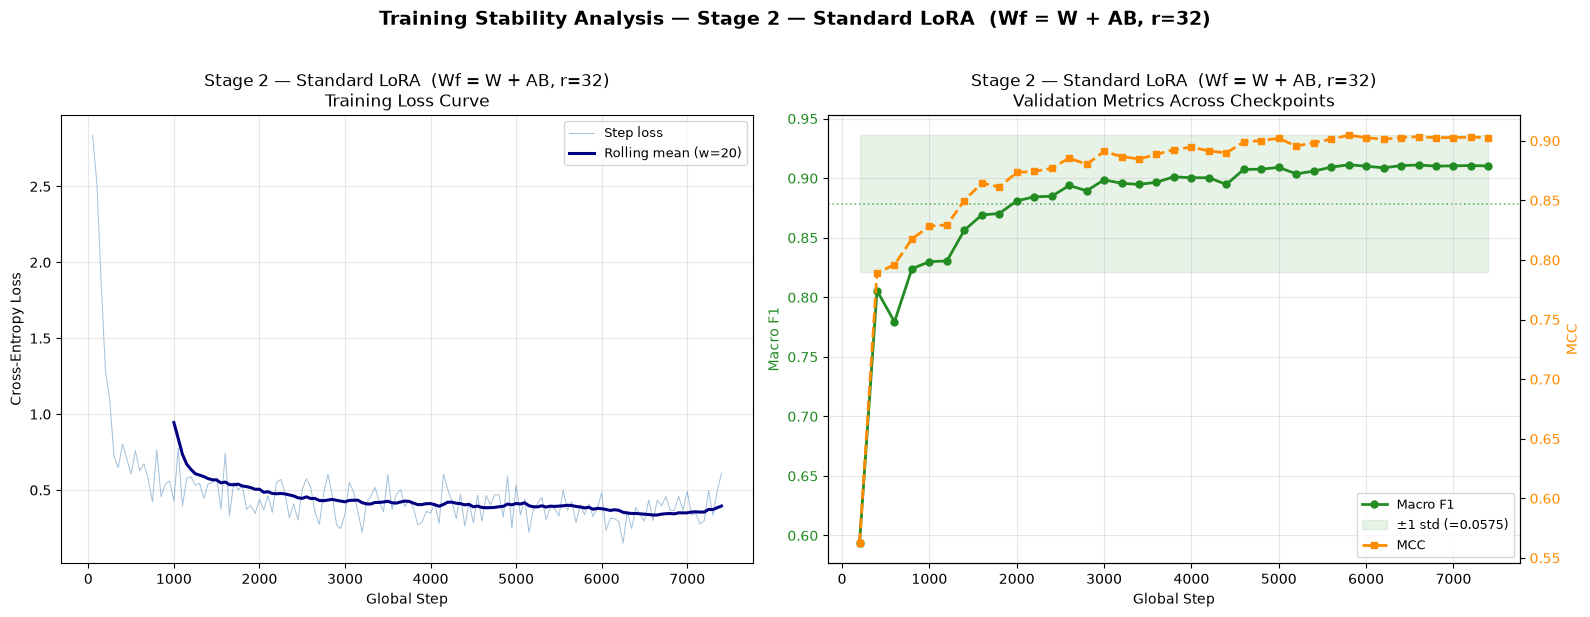

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — DoRA_r32
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9121
  Macro F1          : 0.9014  ← PRIMARY METRIC
  Weighted F1       : 0.9123
  Balanced Accuracy : 0.9017
  MCC               : 0.8942  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7630    0.7549    0.7589      1424
             gender     0.9164    0.9010    0.9086      1788
           religion     0.9589    0.9696    0.9642      1971
          ethnicity     0.9851    0.9884    0.9868      1812
                age     0.9864    0.9662    0.9762      1950
other_cyberbullying     0.7975    0.8303    0.8136      1385

           accuracy                         0.9121     10330
          macro avg     0.9012    0.9017    0.9014     10330


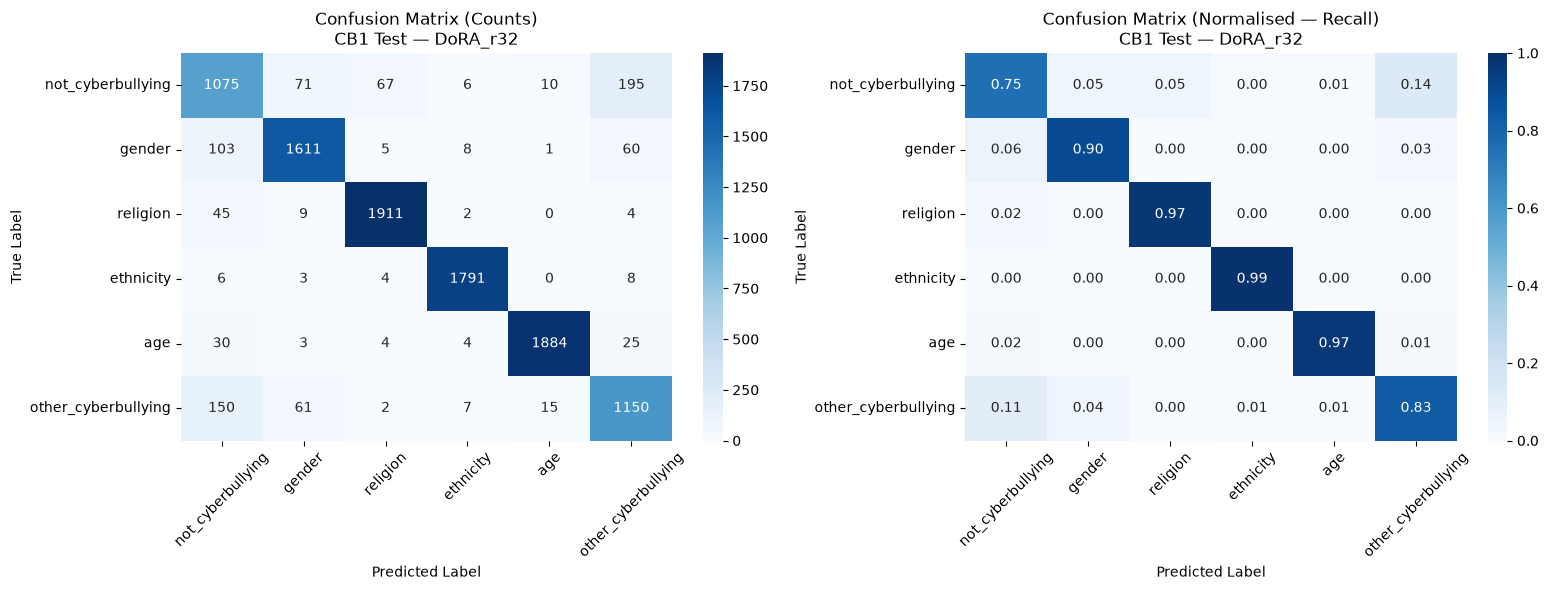


✓ Results saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/DoRA_r32/results_DoRA_r32.csv
   elapsed 4.03 h

--------------------------------------------------------------
  AdaLoRA  at r = 32
--------------------------------------------------------------
   adapter config in use: AdaLoraConfig, init_r=48 -> target_r=32
✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  AdaLoRA_r32
  Model   : google/gemma-2-9b-it
  Rank r  : 32  |  Alpha: 32  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 256,000
   Pad token : "<pad>" (id=0)
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

   update_and_allocate skipped: unsupported operand type(s) for *: 'Parameter' and 'NoneType'


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,2.268000,2.188730,0.266586,0.242440,0.119240
400,1.555000,1.502584,0.466525,0.454287,0.359379
600,0.905900,0.892867,0.704332,0.679555,0.648828
800,0.938000,0.676323,0.797334,0.775501,0.756870
1000,0.533400,0.656958,0.826719,0.806058,0.794483
1200,0.634600,0.563011,0.849137,0.831818,0.819140
1400,0.487300,0.552169,0.853378,0.835892,0.823673
1600,0.642400,0.545412,0.863981,0.846432,0.836914
1800,0.467900,0.519871,0.866101,0.849813,0.839321
2000,0.506300,0.501929,0.873675,0.859862,0.848827


   update_and_allocate skipped: unsupported operand type(s) for *: 'Parameter' and 'NoneType'


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


[5] Computing effective rank of Wf = W + AB...
  ℹ 168 LoRA layers skipped
   avg_effective_rank(Wf) = 0.00
   avg_effective_rank(ΔW) = 0.00  (reference, ≤ r=32)
   LoRA layers measured   = 0

[6] Generating stability report...
   VALIDATION Macro F1 - best: 0.8877 | final: 0.8841   <-- RANK SELECTION USES THIS, NOT THE TEST SCORE
   Loss CV (overall)   : 0.7521100208328194
   Loss std (overall)  : 0.4372259478675503
   Val F1 std          : 0.12493890313502279
   Val MCC std         : 0.1474176903914295
   Composite score     : 0.438524
   Interpretation      : 🔴  Unstable — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/AdaLoRA_r32/stability_curves.png


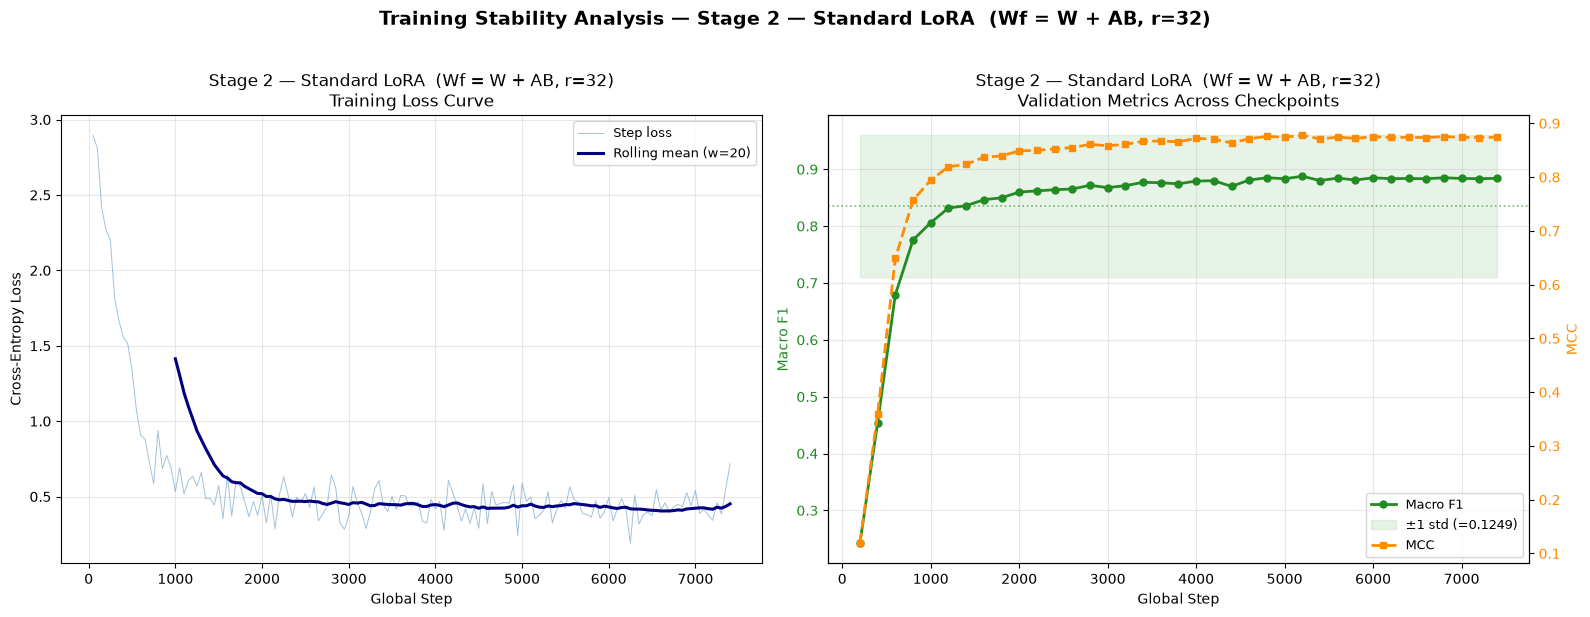

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — AdaLoRA_r32
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.8912
  Macro F1          : 0.8775  ← PRIMARY METRIC
  Weighted F1       : 0.8909
  Balanced Accuracy : 0.8778
  MCC               : 0.8690  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7341    0.6959    0.7145      1424
             gender     0.8936    0.8881    0.8909      1788
           religion     0.9489    0.9619    0.9554      1971
          ethnicity     0.9684    0.9801    0.9742      1812
                age     0.9771    0.9631    0.9700      1950
other_cyberbullying     0.7433    0.7776    0.7601      1385

           accuracy                         0.8912     10330
          macro avg     0.8776    0.8778    0.8775     103

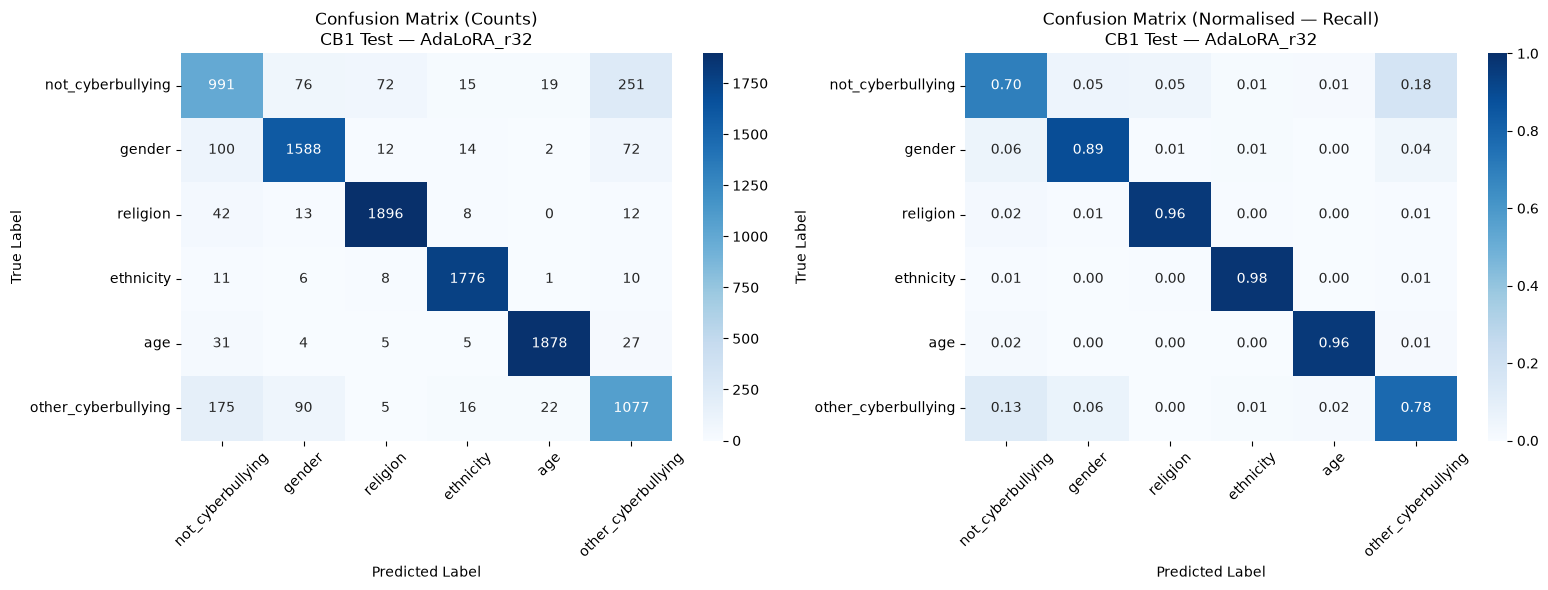


✓ Results saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/AdaLoRA_r32/results_AdaLoRA_r32.csv
   elapsed 7.06 h

PEFT BASELINES vs THE THREE STAGES  --  CB1, Gemma-2-9B, test Macro F1
Method                 |    Trainable |   VAL F1 |  TEST F1 |      MCC | note
AdaLoRA                |   53,703,552 |   0.8877 |   0.8775 |   0.8690 | single seed 42
DoRA                   |   36,298,752 |   0.9113 |   0.9014 |   0.8942 | single seed 42
--------------------------------------------------------------------------------------
Additive LoRA  r=32    |   35,804,160 |          |   0.9007 |          | mean of 3 seeds
Multiplicative r=32    |   39,911,424 |          |   0.8943 |          | mean of 3 seeds
Joint (ours)   r=8     |   18,945,024 |          |   0.9034 |          | mean of 3 seeds

Joint (0.9034) minus each new baseline:
   vs AdaLoRA    +0.0259
   vs DoRA       +0.0020

  Reminder: these baselines are single-seed. The three stages are means of three seeds,
  and rep

In [11]:
# ═════════════════════════════════════════════════════════════════════════════
#  STEP 12. DoRA and AdaLoRA baselines at r = 32
#
#  Both reuse run_standard_lora unchanged. We only swap the adapter config,
#  by monkey-patching LoraConfig for the duration of each call, so every other
#  detail of the protocol is provably identical to the Stage 2 additive run.
#
#  RESUME-SAFE. Re-run this cell after a disconnect; finished methods are
#  reloaded from Drive and skipped.
# ═════════════════════════════════════════════════════════════════════════════
import glob, time, os, math, re
import numpy as np
import peft
from peft import LoraConfig, AdaLoraConfig

RANK        = 32
TOTAL_STEPS = math.ceil(len(train_df) / TRAIN_BATCH_SIZE) * NUM_EPOCHS   # 7426 at batch 4
print(f'total optimizer steps for AdaLoRA schedule: {TOTAL_STEPS}')

# run_standard_lora was compiled with `from peft import LoraConfig`, so it looks
# up the *notebook global* named LoraConfig at call time. Patching peft.LoraConfig
# would therefore do nothing and both runs would silently be plain LoRA.
_ORIG_LoraConfig = LoraConfig

def _make_dora(**kw):
    kw.pop('use_dora', None)
    return _ORIG_LoraConfig(use_dora=True, **kw)

def _make_adalora(**kw):
    kw.pop('r', None)                      # AdaLoRA uses init_r / target_r instead
    return AdaLoraConfig(
        init_r      = 48,                  # start wider ...
        target_r    = RANK,                # ... prune down to the additive budget
        tinit       = int(0.10 * TOTAL_STEPS),   # warm up before pruning begins
        tfinal      = int(0.30 * TOTAL_STEPS),   # stop pruning here, then fine-tune
        deltaT      = 10,
        total_step  = TOTAL_STEPS,
        **kw)

METHODS = {
    'DoRA':    _make_dora,
    'AdaLoRA': _make_adalora,
}

# AdaLoRA prunes singular values through update_and_allocate(), which the HF
# Trainer does not call on its own. Without this callback AdaLoRA never
# reallocates and is simply LoRA at r=48. Registered only for the AdaLoRA run.
from transformers import TrainerCallback as _TC
class AdaLoraAllocCallback(_TC):
    def on_step_end(self, args, state, control, **kw):
        mdl = kw.get('model', None)
        if mdl is None: return
        tgt = getattr(mdl, 'base_model', mdl)
        fn  = getattr(tgt, 'update_and_allocate', None)
        if callable(fn):
            try: fn(state.global_step)
            except Exception as e:
                if state.global_step < 3: print('   update_and_allocate skipped:', e)

_ORIG_CustomTrainer = CustomTrainer
class _AdaLoraTrainer(_ORIG_CustomTrainer):
    def __init__(self, *a, **kw):
        cbs = list(kw.pop('callbacks', []) or [])
        cbs.append(AdaLoraAllocCallback())
        super().__init__(*a, callbacks=cbs, **kw)

# ── recover anything already finished ───────────────────────────────────────
def _norm(d):
    g = lambda *ks: next((d[k] for k in ks if k in d and d[k] is not None), None)
    return {'val_best':  g('val_f1_best','val_macro_f1_best'),
            'macro_f1':  g('macro_f1'), 'mcc': g('mcc'), 'accuracy': g('accuracy'),
            'trainable_params': g('trainable_params')}

results = {}
for p in sorted(glob.glob(os.path.join(OUTPUT_DIR, '*', '*results*.csv'))):
    name = os.path.basename(os.path.dirname(p))
    for m in METHODS:
        if name.startswith(m):
            try:
                d = _norm(pd.read_csv(p).iloc[0].to_dict())
            except Exception:
                continue
            v = d['val_best']
            if v is None or (isinstance(v, float) and math.isnan(v)):
                continue
            results[m] = d

print('recovered      :', sorted(results))
missing = [m for m in METHODS if m not in results]
print('still to run   :', missing)

# ── run what is missing ─────────────────────────────────────────────────────
_t0 = time.time()
for m in missing:
    print(f'\n{"-"*62}\n  {m}  at r = {RANK}\n{"-"*62}')
    globals()['LoraConfig'] = METHODS[m]          # swap the adapter, nothing else
    globals()['CustomTrainer'] = _AdaLoraTrainer if m == 'AdaLoRA' else _ORIG_CustomTrainer
    _probe = LoraConfig(r=RANK, lora_alpha=RANK, target_modules=TARGET_MODULES,
                        lora_dropout=LORA_DROPOUT, bias='none', task_type='SEQ_CLS')
    print(f'   adapter config in use: {type(_probe).__name__}'
          + (f', use_dora={getattr(_probe, "use_dora", None)}' if m == 'DoRA'
             else f', init_r={_probe.init_r} -> target_r={_probe.target_r}'))
    assert type(_probe).__name__ != 'LoraConfig' or getattr(_probe, 'use_dora', False), \
        'adapter swap failed: still plain LoRA'
    try:
        results[m] = _norm(run_standard_lora(
            train_df=train_df, val_df=val_df, test_df=test_df,
            lora_rank=RANK, run_label=f'{m}_r{RANK}'))
    finally:
        globals()['LoraConfig']   = _ORIG_LoraConfig   # always restore
        globals()['CustomTrainer'] = _ORIG_CustomTrainer
    print(f'   elapsed {(time.time()-_t0)/3600:.2f} h')

# ── summary against the three stages ────────────────────────────────────────
REF = {'Additive LoRA  r=32': (35_804_160, 0.9007, 'mean of 3 seeds'),
       'Multiplicative r=32': (39_911_424, 0.8943, 'mean of 3 seeds'),
       'Joint (ours)   r=8 ': (18_945_024, 0.9034, 'mean of 3 seeds')}

print('\n' + '='*86)
print('PEFT BASELINES vs THE THREE STAGES  --  CB1, Gemma-2-9B, test Macro F1')
print('='*86)
print(f'{"Method":22} | {"Trainable":>12} | {"VAL F1":>8} | {"TEST F1":>8} | {"MCC":>8} | note')
for m in sorted(results):
    a = results[m]
    print(f'{m:22} | {float(a["trainable_params"]):>12,.0f} | {float(a["val_best"]):>8.4f} | '
          f'{float(a["macro_f1"]):>8.4f} | {float(a["mcc"]):>8.4f} | single seed 42')
print('-'*86)
for k,(pr,f1,note) in REF.items():
    print(f'{k:22} | {pr:>12,} | {"":>8} | {f1:>8.4f} | {"":>8} | {note}')

print('\nJoint (0.9034) minus each new baseline:')
for m in sorted(results):
    print(f'   vs {m:10} {0.9034 - float(results[m]["macro_f1"]):+.4f}')
print('\n  Reminder: these baselines are single-seed. The three stages are means of three seeds,')
print('  and repeated runs of one configuration differ by about 0.001 Macro F1. Read any gap')
print('  below roughly 0.002 as indistinguishable.')

pd.DataFrame([{'method': m,
               'trainable_params': results[m]['trainable_params'],
               'val_macro_f1':     results[m]['val_best'],
               'test_macro_f1':    results[m]['macro_f1'],
               'test_mcc':         results[m]['mcc']} for m in sorted(results)]
            ).to_csv(os.path.join(OUTPUT_DIR, 'peft_baselines_r32.csv'), index=False)
print('\nSaved -> peft_baselines_r32.csv')
